<a href="https://colab.research.google.com/github/Kidkudos77/personalportfolio/blob/main/Chapter2_Inference_Categorial_Data_cls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## This is a notebook showing the example of estimating parameters for Categorical and Multinomial distributions (including binomial distribution). It includes
*   How to generate data that follows categorical distribution
*   How to estimate distribution parameters for each state by the frequentist approach
*   How to estimate the distribution parameters by Bayesian approach

Finally, you will compare the results among frequentist approach, Bayesian approach, and true value (Ground truth).


# **Part 1: Generation of data following categorical distribution**

In [4]:
import numpy as np
import scipy.stats as stats

# discrete random variable with K states
# generate the test results as 50 binary random numbers  (x = 1: test positive, x=0: test negative)
N = 50
K = 5

states = np.arange(K) # just output 0, 1, 2, 3, 4 for 5 states
params_alpha = 0.5*np.ones(K,)  # Provide parameters alpha, 0.5, 0.5, 0.5, 0.5, 0.5
# Use alpha to generate mu (probability that each state at state 1) by drawing a sample
# from Dirichlet distribution
# Note: five mu's generated sum up to 1
mu_probs  = np.random.dirichlet(params_alpha)

print('Parameters Mu for Categorical Distribution are:', mu_probs)
#generate data following categorical distribution
categoricaldist = stats.rv_discrete(name='categorical', values=(states, mu_probs))
x = categoricaldist.rvs(size=N)
print('The data following categorical distribution are: ')
print(x)

Parameters Mu for Categorical Distribution are: [0.32427346 0.04747389 0.01609958 0.60628482 0.00586825]
The data following categorical distribution are: 
[0 0 3 0 3 0 3 1 3 1 3 3 3 0 3 0 0 1 3 3 0 3 3 0 3 3 1 0 3 3 1 3 0 3 3 0 0
 3 3 3 3 2 3 3 3 3 3 1 3 0]


** Question: What do the data generated mean? **

The generated data represents the results of 50 independent trials, where each number indicates which of the 5 possible states (0 through 4) occured in that specific trial.

** Please fill out the information below after the question mark **
** For each data, the probability of the data in **

state 4 is 0.05905435

State 3 is 0.16695668

State 2 is 0.66663408

State 1 is 0.05531507

State 0 is 0.05203981

# **Part 2: Frequentist approach to estimate parameter (Maximum Likelihood)**

In [5]:
# Estimate the parameter of the categorical distribution from data x
# The maxmimum likelhood estimate purely depends on the data
# Report you MLE estimates of all the parameters involved in categorical distribution
unique, mk = np.unique(x, return_counts=True) # Count the number of times x falls in each state

# use formula in Slide 20 in Chapter_2_Inference
MLE = mk/N
print('The MLE estimation for mu is:', MLE)

for value, mle in zip(unique, MLE):
    print(f"State: {value}, MLE for Mu: {mle}")

The MLE estimation for mu is: [0.28 0.12 0.02 0.58]
State: 0, MLE for Mu: 0.28
State: 1, MLE for Mu: 0.12
State: 2, MLE for Mu: 0.02
State: 3, MLE for Mu: 0.58


# **Part 3: Bayesian approach to estimate model parameter**

In [6]:
# Bayesian Estimate uses some prior knowledge on the positive rate
# Report your MAP estimate for all parameters in the categorical distribution in this example
from scipy.stats import dirichlet
m = dict(zip(unique,mk))
alpha = dict(zip(states,params_alpha)) # create a dictionary for m
MAP_Numerator = {}
# apply formula in (2.11)
for k in states:
    if k in m and m[k] != 0:
        MAP_Numerator[k] = alpha[k] + mk[k] -1

# Remember MAP = alpha + mk - 1
MAP = {int(k): float(v/sum(MAP_Numerator.values())) for k, v in MAP_Numerator.items()}



# **Part 4: Comparison of all results and summarize.**

In [8]:
# Compare all the estimation and then answer: Which one is closer to the true value?
print('The MLE estimator of Mu is:', MLE)
print('The MAP estimator for Mu is:', MAP)
print('The true Mu is',  mu_probs)

The MLE estimator of Mu is: [0.28 0.12 0.02 0.58]
The MAP estimator for Mu is: {0: 0.28125, 1: 0.11458333333333333, 2: 0.010416666666666666, 3: 0.59375}
The true Mu is [0.32427346 0.04747389 0.01609958 0.60628482 0.00586825]


# **Part 5: Count Data**
Frequentist approach
Bayesian approach

In [13]:
counts = np.bincount(x, minlength=K)
mu_MLE = counts/N
print(' MLE of mu= '+ np.array2string(mu_MLE, precision=4))

# Bayesian approach
# Assume a flat prior for alpha in Dirichlet distribution
alpha = np.ones(K)
# Formula on Slide 30
mu_MAP = (alpha + counts - 1) / np.sum(alpha + counts -1)
# Set negative values to 0
mu_MAP[mu_MAP < 0] = 0
# Normalize the mu_MAP
mu_MAP = mu_MAP / np.sum(mu_MAP)
print('MAP of mu= '+ np.array2string(mu_MAP, precision=4))

 MLE of mu= [0.28 0.12 0.02 0.58 0.  ]
MAP of mu= [0.28 0.12 0.02 0.58 0.  ]


**Estimating Binomial Parameters Using MLE and MAP**

You are tasked with estimating the success probability θ of a binomial process using both Maximum Likelihood Estimation (MLE) and Maximum A Posteriori (MAP) estimation. The dataset consists of 10 trials of a coin flip experiment, with 7 observed successes.

**Your goal** is to:

Plot the likelihood (Binomial distribution) based on the observed data and visually estimate θ by identifying the maximum value on the plot (MLE).
Incorporate prior information (Beta distribution) to compute the posterior distribution and visually estimate θ from the posterior plot (MAP).
Compare the estimates of θ from the plots with the theoretical values derived from MLE and MAP formulas.
Task Breakdown:
Dataset:
Number of trials (n): 10
Number of successes (k): 7

**Tasks:**
1. Binomial Likelihood and MLE Estimation:
Compute the Binomial likelihood for different values of θ (success probability) ranging from 0 to 1. Plot the likelihood function. From the plot, visually estimate the value of θ that maximizes the likelihood (this is your MLE estimate).Compute the theoretical MLE. Compare the MLE estimate from the plot with the theoretical MLE.

2. Beta Prior and Posterior Estimation:
Assume a Beta prior distribution with parameters α=1 and β=1 (a uniform prior).
Compute the posterior distribution (Beta distribution) by updating the prior with the observed data. Plot the posterior distribution. Visually estimate the value of θ that maximizes the posterior (this is your MAP estimate).
Compute the theoretical MAP estimate
Compare the MAP estimate from the plot with the theoretical MAP.
Comparison: Present the estimated θ values from the plots (using argmax) and the theoretical values from the formulas for both MLE and MAP.
Discuss any differences or similarities between the values.

**What You Should Submit:**
*   The plots of the likelihood function and posterior distribution.

*   The MLE and MAP estimates obtained from the plots and the theoretical formulas.
*   A brief discussion comparing the results of MLE and MAP from both the visual and theoretical approaches.





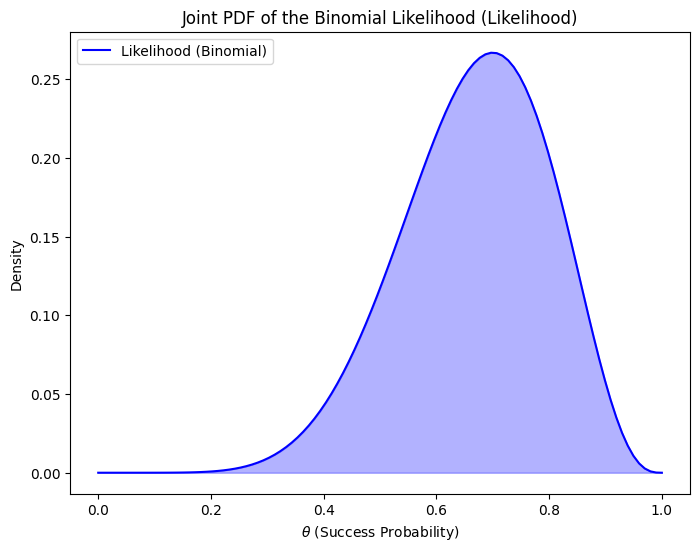

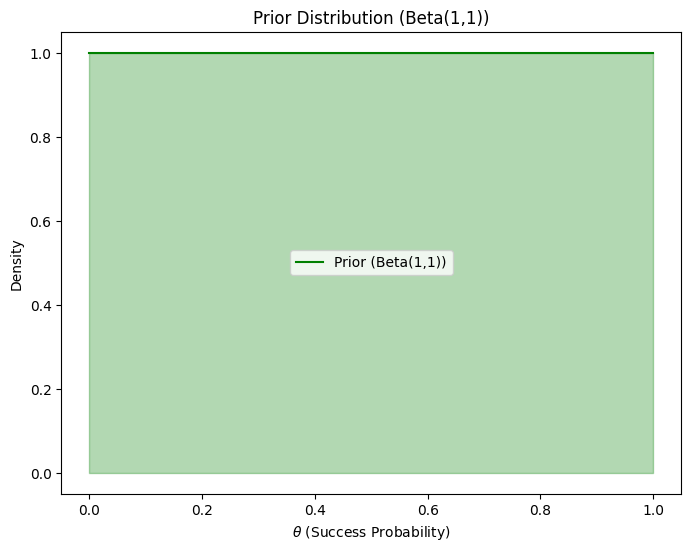

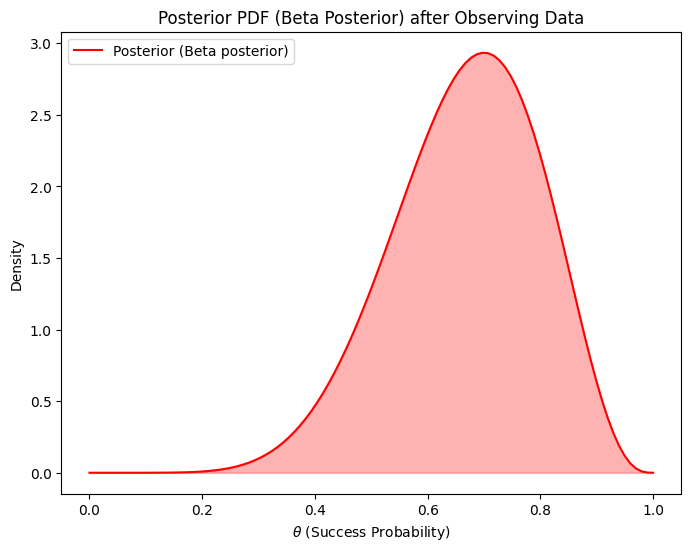

Theoretical binomial parameters by MLE: theta_MLE = 0.7000
Estimated binomial parameters by MAP: theta_MAP = 0.7000

Comparison:
MLE Theta (from plot): 0.6970, Theoretical MLE Theta: 0.7000
MAP Theta (from plot): 0.6970, Theoretical MAP Theta: 0.7000


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, beta

# Generate observed data (Binomial) for a coin flip example
n = 10  # Number of trials
k = 7 # Number of successes (observed data)

# Define 100 candidate theta values (success probability) ranging from 0 to 1.
theta_values = np.linspace(0, 1, 100)

# 1 Calculate the likelihood (Binomial distribution) binom.pmf
likelihood_values = binom.pmf(k, n, theta_values)

# Plot the joint PDF of the likelihood (Binomial)
plt.figure(figsize=(8, 6))
plt.plot(theta_values, likelihood_values, label='Likelihood (Binomial)', color='blue')
plt.fill_between(theta_values, likelihood_values, alpha=0.3, color='blue')
plt.title('Joint PDF of the Binomial Likelihood (Likelihood)')
plt.xlabel(r'$\theta$ (Success Probability)')
plt.ylabel('Density')
plt.legend()
plt.show()

# Find the MLE by argmax from the likelihood plot
mle_theta_plot =  theta_values[np.argmax(likelihood_values)]

# 2 Calculate the prior (Beta distribution with alpha=1, beta=1) beta.pdf
alpha_prior = 1   # Parameters for Beta(1,1)
beta_prior = 1
prior_values = beta.pdf(theta_values, alpha_prior, beta_prior)

# Plot the Beta prior
plt.figure(figsize=(8, 6))
plt.plot(theta_values, prior_values, label='Prior (Beta(1,1))', color='green')
plt.fill_between(theta_values, prior_values, alpha=0.3, color='green')
plt.title('Prior Distribution (Beta(1,1))')
plt.xlabel(r'$\theta$ (Success Probability)')
plt.ylabel('Density')
plt.legend()
plt.show()

# 3 Calculate the posterior (Beta posterior) with updated alpha and beta
alpha_posterior = alpha_prior + k
beta_posterior = beta_prior + n - k
posterior_values = beta.pdf(theta_values, alpha_posterior, beta_posterior)

# Plot the posterior PDF of the Beta posterior (MAP)
plt.figure(figsize=(8, 6))
plt.plot(theta_values, posterior_values, label='Posterior (Beta posterior)', color='red')
plt.fill_between(theta_values, posterior_values, alpha=0.3, color='red')
plt.title('Posterior PDF (Beta Posterior) after Observing Data')
plt.xlabel(r'$\theta$ (Success Probability)')
plt.ylabel('Density')
plt.legend()
plt.show()

# Find the MAP by argmax from the posterior plot
map_theta_plot = theta_values[np.argmax(posterior_values)]

# 4 Perform Maximum Likelihood Estimation (MLE) using theoretical equation
mle_theta = k / n # MLE for theta (success probability)
print(f"Theoretical binomial parameters by MLE: theta_MLE = {mle_theta:.4f}")

# 5 Perform Maximum A Posteriori (MAP) using theoretical equation
map_theta = (alpha_posterior - 1) / (alpha_posterior + beta_posterior - 2)
print(f"Estimated binomial parameters by MAP: theta_MAP = {map_theta:.4f}")

# 6 Comparison of Results
print(f"\nComparison:")
print(f"MLE Theta (from plot): {mle_theta_plot:.4f}, Theoretical MLE Theta: {mle_theta:.4f}")
print(f"MAP Theta (from plot): {map_theta_plot:.4f}, Theoretical MAP Theta: {map_theta:.4f}")

The Maximum Likelihood Estimation (MLE) approach relies on the counting data I observed. Since there were 7 successes out of 10 trials that gives us the theoretical MLE of 0.7000. When I applied the Bayesian approach, MAP (Maximum A Posteriori),  by combining that counting data with a "prior" where alpha = 1 and beta = 1 (which represents our starting assumption before running the experiment), it didn't sway my results in any direction. As a result, there was no bias, and the theoretical MAP estimate ended up being the same as the MLE at 0.7000.  This could also be seen in our visual graph plots.

**1. Can we use plots to find MLE and Bayesian estimates, as we did in Unit 2? Why? (2 pts) **

Yes, we can use plots to find MLE and Bayesian estimates. The blue curve and red curve which represent the likelihood function and posterior distribution, can be plotted out to show us the probability or density of eery possible parameter value from 0 to 1. The highest peak on each graph lets us know the MLE and MAP because that peak is the maximum likelihood or posterior.

** 2. How are these distributions, Bernoulli, Categorical, and multinomial distributions, related? (2 pts) **

Bernoulli, categorical, and multinomial distributions are related because they model discrete outcomes. Essentially, it involves adjusting the mathematical technique to how many choices are available and how many times the experiment is repeated.